# Funksjonsanalyse i Python

# Introduksjon
Numerisk funksjonsanalyse

## TODO
* Beskrive forkunnskaper
* Koble til læreplan
  

# Å definere og plotte en funksjon i Python

## Å definere en funksjon og lage en verditabell
I eksempelet under har vi definert en funksjon f som returnerer $4 - x^2$, laget en verditabell for x-verdier og y-verdier:

In [1]:
# importerer nødvendige biblioteker
import numpy as np

# definerer funksjonen vår
def f(x):
    return 4 - x**2

x = np.linspace(-4,4,9)

# her sender vi x-tabellen inn i funksjonen, og lagrer funksjonsverdiene i en y-tabell
y = f(x)

print(x)
print(y)

[-4. -3. -2. -1.  0.  1.  2.  3.  4.]
[-12.  -5.   0.   3.   4.   3.   0.  -5. -12.]


```{tip} Oppgave
Kopier koden til ditt pythonprogram, og prøv å endre på verdien i koden, både på parameterene i linspace() og på selve funksjonsuttrykket og se hva som skjer
```

## Å plotte funksjoner
I programmet nedenfor har jeg lagt til følgende kode nederst i programmet.
```{code-block}Python
plt.plot(x,y, color="red")
plt.axvline(x=0, color="black")
plt.axhline(y=0, color="black")
plt.show()
```

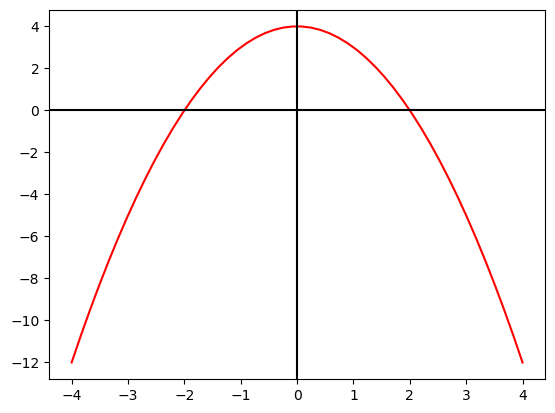

In [3]:
# importerer nødvendige biblioteker
import numpy as np
import matplotlib.pyplot as plt

# definerer funksjonen vår
def f(x):
    return 4 - x**2

x = np.linspace(-4,4,50)

# her sender vi x-tabellen inn i funksjonen, og lagrer funksjonsverdiene i en y-tabell
y = f(x)

plt.plot(x,y, color="red")      # lager et x-y plott med rød farge
plt.axvline(x=0, color="black") # tegner x-aksen i svart
plt.axhline(y=0, color="black") # Tegner y-aksen i svart
plt.show()                      # Viser plottet 

```{tip} Oppgave
Kjør koden på egen maskin. Prøv å endre på forskjellige ting i koden, som feks parametere i linspace() eller selve funksjonen!
```

# Å finne nullpunkter i funksjonen
Nedenfor har vi to måter å finne nullpunkter på

## Nullpunkter ved fortegnsskift - metode 1
I verditabellen kan vi være heldige, og finne en y-verdi som er akkurat null, men som regel er dette ikke tilfelle. Vi kan imidlertid se på fortegnsskifte: dersom en y-verdi har forskjellig fortegn enn den neste, så har funksjonen krysset x-aksen. Følgende kode bruker np.sign() funksjonen for å finne fortegnet til y-verdien og sjekker for fortegnsskift.

Dersom vi har fortegnsskift må nullpunktet ligge MELLOM de tilhørende x-verdiene, derfor tar vi gjennomsnittet av disse to for å få et mer nøyaktig resultat. Dersom vi er så heldige at vi har et eksakt nullpunkt i tabellsettet, så får vi nødvendigvis ikke fortegnsskift derfor må vi teste for dette også i elif-blokken under.

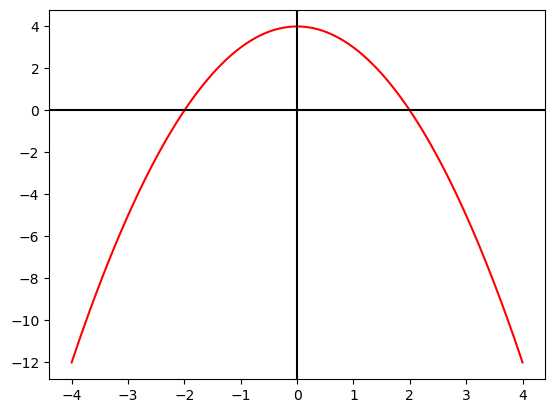

nullpunkt x = -2.02020202020202
nullpunkt x = 2.0202020202020208


In [2]:
# Importerer biblioteker
import numpy as np
import matplotlib.pyplot as plt
# Definerer funksjoner
def f(x):
    return 4 - x**2

# Antall elementer i x og y-tabellene
N = 100
# Lager x-tabell
x = np.linspace(-4,4,N)
# Lager y-tabell med tilhørende funksjonsverdier
y = f(x)
# Plotter grafen (ser om det faktisk finnes nullpkt)
plt.plot(x,y, color="red")
plt.axvline(x=0, color="black")
plt.axhline(y=0, color="black")
plt.show()
# Itererer y-tabellen for å finne fortegnsskift eller 0
for i in range(N-1):
    if np.sign(y[i]) != np.sign(y[i+1]):
        # Tar gjennomsnittet av x[i] og x[i+1]
        nullp = (x[i]+x[i+1])/2
        print("nullpunkt x = " + str(nullp))
    # sjekker også etter reelt nullpunkt
    elif y[i] == 0:
        print("nullpunkt x = " + str(x[i]))

## Nullpunkter ved fortegnsskift (snedig)
Man trenger ikke bruke sign(), men vi kan bruke fortegnsreglene for produkter til å lage en enklere test. Dersom y og neste y har samme fortegn, så vil produktet alltid være positivt. Dersom vi har et fortegnsskift mellom y og neste y, så vil produktet være negativt. Koden under viser hvordan dette kan gjøres:

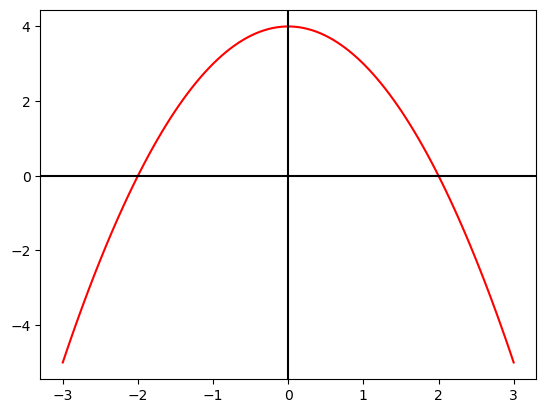

nullpunkt x = -2.0
nullpunkt x = 2.0


In [3]:
# Importerer biblioteker
import numpy as np
import matplotlib.pyplot as plt
# Definerer funksjoner
def f(x):
    return 4 - x**2

# Antall elementer i x og y-tabellene
N = 106
# Lager x-tabell
x = np.linspace(-3,3,N)
# Lager y-tabell med tilhørende funksjonsverdier
y = f(x)
# Plotter grafen (ser om det faktisk finnes nullpkt)
plt.plot(x,y, color="red")
plt.axvline(x=0, color="black")
plt.axhline(y=0, color="black")
plt.show()
# Itererer y-tabellen for å finne fortegnsskift eller 0
for i in range(N-1):
    if y[i] * y[i+1] < 0:
        # Tar gjennomsnittet av x[i] og x[i+1]
        nullp = (x[i]+x[i+1])/2
        print("nullpunkt x = " + str(nullp))
    # sjekker også etter reelt nullpunkt
    elif y[i] == 0:
        print("nullpunkt x = " + str(x[i]))

Nå har vi to versjoner av et verktøy som kan finne nullpunkter på alle funksjoner, i definisjonsområdet til x. 

````{tip} Oppgave
Nå kan du prøve ut andre funksjonsuttrykk, bare husk på at du må sjekke plottet og eventuelt justere definsjonsområdet i linspace() slik at nullpunktene faktisk eksisterer i datasettet.
Prøv for eksempel $f(x)=cos⁡(x)+x$
Dette er en såkalt transcendental likning, som ikke er mulig å løse analytisk. Koden for å bruke cosinus i Python er:
```{code-block}Python
y = np.cos(x) + x
```
````

# Numerisk derivasjon (momentan vekstfart)